# Simple Linear Regression: From Intuition to Implementation

This notebook breaks down Simple Linear Regression into bite-sized mathematical and visual concepts.

## 1. Problem Statement

Given training data:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}
$$

We want to find a straight line that **best represents** the relationship between our input feature ($x$) and the target output ($y$).

## 2. What is Linear Regression?

> **Important Note:** *Simple* Linear Regression specifically deals with **one single input feature** to predict **one target output**. (When you have multiple inputs, it becomes *Multiple* Linear Regression).

Linear regression assumes that the relationship between variables is linear. Mathematically, our model is represented as:

$$
\hat{y} = mx + b
$$

Where:
- $x$ = input feature (independent variable)
- $\hat{y}$ = predicted output (dependent variable)
- $m$ = slope (weight)
- $b$ = intercept (bias)

## 3. Understanding $m$ and $b$

- **Intercept ($b$)**: The expected value of $y$ when $x=0$.
- **Slope ($m$)**: How much $y$ is expected to change for a one-unit change in $x$.

## 4. Dataset

Let's start by defining a simple toy dataset to visualize the concepts.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Let's create a simple dataset with 1 Input Feature (Hours Studied) and 1 Target Output (Exam Score)
data = {
    "Hours_Studied": [2.5, 5.1, 3.2, 8.5, 3.5, 1.5, 9.2, 5.5, 8.3, 2.7],
    "Exam_Score": [21, 47, 27, 75, 30, 20, 88, 60, 81, 25]
}

df = pd.DataFrame(data)

# For mathematical formulas below, we will extract them as numpy arrays (x and y)
x = df["Hours_Studied"].values
y = df["Exam_Score"].values

display(df)

,Hours_Studied,Exam_Score
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


## 5. Visualizing the Dataset

Before fitting any model, it's always a good idea to look at the raw data.

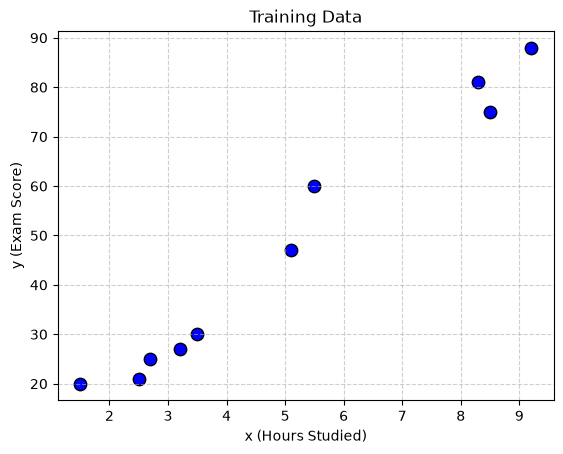

In [20]:
plt.scatter(x, y, color='blue', edgecolor='k', s=80)
plt.xlabel("x (Hours Studied)")
plt.ylabel("y (Exam Score)")
plt.title("Training Data")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6. What is Prediction?

A prediction $\hat{y}_i$ is what our line *guesses* the output should be for a specific $x_i$, given a chosen $m$ and $b$.

$$
\hat{y}_i = m x_i + b
$$

## 7. What is Error? (Residuals)

The error (or residual) is the difference between the actual value $y_i$ and our predicted value $\hat{y}_i$.

$$
e_i = y_i - \hat{y}_i
$$

Let's visualize what an error looks like for an arbitrary line (e.g., $m=7, b=10$).

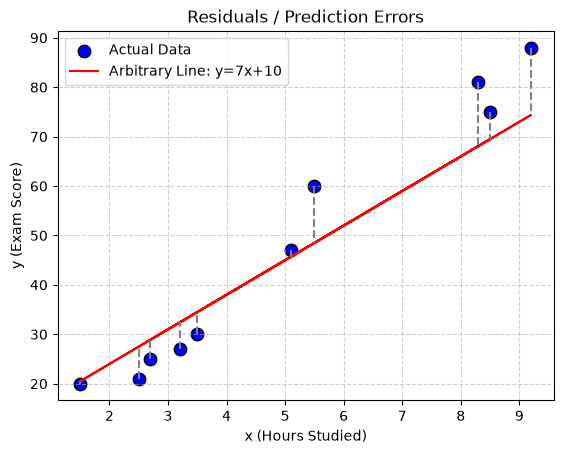

In [21]:
m_arbitrary = 7
b_arbitrary = 10
y_pred_arbitrary = m_arbitrary * x + b_arbitrary

plt.scatter(x, y, color='blue', edgecolor='k', s=80, label="Actual Data")
plt.plot(x, y_pred_arbitrary, color='red', label=f"Arbitrary Line: y={m_arbitrary}x+{b_arbitrary}")

# Plot residuals
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y[i], y_pred_arbitrary[i]], color='gray', linestyle="--")

plt.xlabel("x (Hours Studied)")
plt.ylabel("y (Exam Score)")
plt.title("Residuals / Prediction Errors")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Each dashed line above represents the error $e_i$. Some are positive, some are negative.

## 8. Why Squared Error?

If we just added up the raw errors, positive and negative errors would cancel each other out! To fix this, we could use absolute values $|e_i|$, but mathematically, it's easier to use **squared errors** ($e_i^2$).

Squaring the errors also heavily penalizes *large* errors, forcing the line to fit the data better.

## 9. Cost / Loss Function

The Sum of Squared Errors (SSE) tells us how bad our line is overall. Our goal is to minimize this cost.

$$
J(m,b) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - (mx_i + b))^2
$$

Our objective:
$$
\boxed{\min_{m,b} J(m,b)}
$$

## 10. Mathematical Derivation

To find the minimum of the cost function $J$, we take the partial derivatives with respect to $m$ and $b$, and set them to zero.

### Deriving $b$

$$
\frac{\partial J}{\partial b} = -2 \sum_{i=1}^{n} (y_i - mx_i - b) = 0
$$

Dividing by -2 and distributing the sum:
$$
\sum y_i - m \sum x_i - n b = 0 \implies n b = \sum y_i - m \sum x_i
$$

Divide by $n$ (since $\frac{\sum x_i}{n} = \bar{x}$ and $\frac{\sum y_i}{n} = \bar{y}$):
$$
\boxed{b = \bar{y} - m\bar{x}}
$$

### Deriving $m$

$$
\frac{\partial J}{\partial m} = -2 \sum_{i=1}^{n} x_i (y_i - mx_i - b) = 0
$$

Substituting $b = \bar{y} - m\bar{x}$ into the equation and simplifying leads to:

$$
\boxed{m = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}}
$$

## 11. Compare Different Lines

Every possible pair of $(m, b)$ gives a different line and therefore a different loss $J(m, b)$. Let's see how changing the slope affects the line.

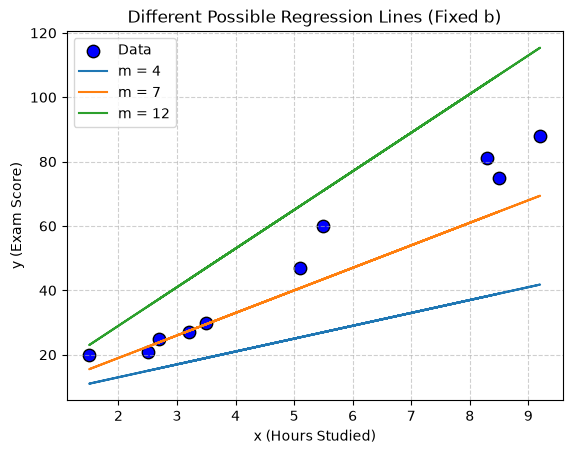

In [22]:
m_values = [4, 7, 12]
b_fixed = 5

plt.scatter(x, y, color='blue', edgecolor='k', s=80, label="Data")

for m_val in m_values:
    y_line = m_val * x + b_fixed
    plt.plot(x, y_line, label=f"m = {m_val}")

plt.xlabel("x (Hours Studied)")
plt.ylabel("y (Exam Score)")
plt.title("Different Possible Regression Lines (Fixed b)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 12. Loss vs m (The U-Shaped Curve)

Let's calculate the cost $J$ for a range of slope values to see why a "best" slope exists.

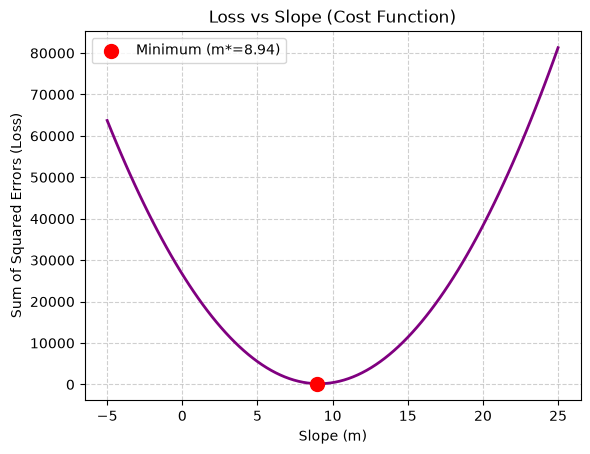

In [23]:
m_range = np.linspace(-5, 25, 100)
losses = []

b_calc = y.mean() - 9 * x.mean() # Approximate b for this demo

for m_val in m_range:
    y_pred_temp = m_val * x + b_calc
    loss = np.sum((y - y_pred_temp) ** 2)
    losses.append(loss)

plt.plot(m_range, losses, color='purple', linewidth=2)
plt.xlabel("Slope (m)")
plt.ylabel("Sum of Squared Errors (Loss)")
plt.title("Loss vs Slope (Cost Function)")
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the minimum
min_loss_idx = np.argmin(losses)
plt.scatter(m_range[min_loss_idx], losses[min_loss_idx], color='red', s=100, zorder=5, label=f"Minimum (m*={m_range[min_loss_idx]:.2f})")
plt.legend()
plt.show()

This characteristic **U-shaped curve** shows that there is a single global minimum. Mathematically:

$$
\boxed{m^* = \arg\min_m J(m)}
$$

This is the core concept behind optimization techniques like **Gradient Descent**!

## 13. Visualizing the Mean Point

An interesting property of the best-fit line is that it always passes through the mean of the data: $(\bar{x}, \bar{y})$. Let's see it!

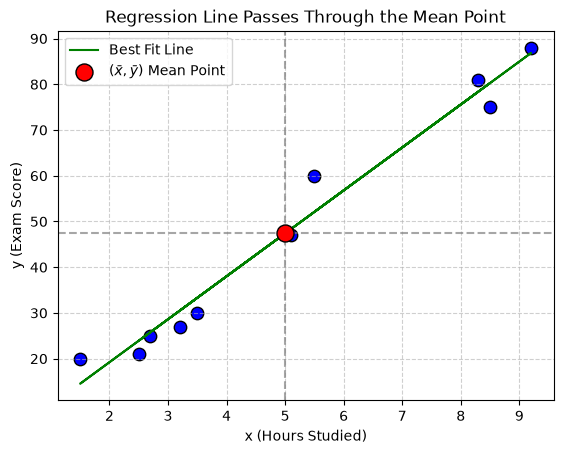

In [24]:
x_mean = x.mean()
y_mean = y.mean()

# Calculate exact m and b using the derived formulas
m_best = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
b_best = y_mean - m_best * x_mean
y_best = m_best * x + b_best

plt.scatter(x, y, color='blue', edgecolor='k', s=80)
plt.plot(x, y_best, color='green', label="Best Fit Line")

# Highlight mean point
plt.scatter(x_mean, y_mean, color='red', s=150, edgecolor='k', zorder=5, label=r"$(\bar{x},\bar{y})$ Mean Point")
plt.axvline(x_mean, color='gray', linestyle="--", alpha=0.7)
plt.axhline(y_mean, color='gray', linestyle="--", alpha=0.7)

plt.xlabel("x (Hours Studied)")
plt.ylabel("y (Exam Score)")
plt.title("Regression Line Passes Through the Mean Point")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 14. Implement From Scratch

Now it's time to put all this math into Python code by building our own `SimpleRegression` class!

In [25]:
class SimpleRegression:
    def __init__(self):
       self.m = None
       self.b = None
    
    def fit(self,x_train,y_train):
        size = len(x_train)
        num = 0
        denom = 0
        for i in range(0,size):
            num += (x_train[i]-x_train.mean())*(y_train[i]-y_train.mean())
            denom += (x_train[i]-x_train.mean())*(x_train[i]-x_train.mean())
        self.m = num/denom
        self.b = y_train.mean()-self.m*x_train.mean()
        print("slope:",self.m)
        print("Intercept:",self.b)
    
    def predict(self,x_test):
        return self.m*x_test+self.b

## 15. Train Your Model

In [31]:
from sklearn.model_selection import train_test_split
# splitting The Dataset For Train and Test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

train = SimpleRegression()
train.fit(x_train,y_train)

slope: 9.309518543095185
Intercept: 1.4482415394824173


## 16. Predict

In [34]:
train.predict(x_test)

array([34.03155644, 48.92678611])

## 17. Verify With sklearn 

*`sklearn.linear_model.LinearRegression`.*

In [46]:
from sklearn.linear_model import LinearRegression

Lr = LinearRegression()

Lr.fit(x_train.reshape(-1, 1), y_train)
y_pred=Lr.predict(x_test.reshape(-1,1))
print(y_pred)

[34.03155644 48.92678611]


### Both Predicted The same Values means our simple regression we made from base is correct

## 18. Actual vs Predicted

*Plotting actual y values vs predicted y values to visually evaluate the performance.*

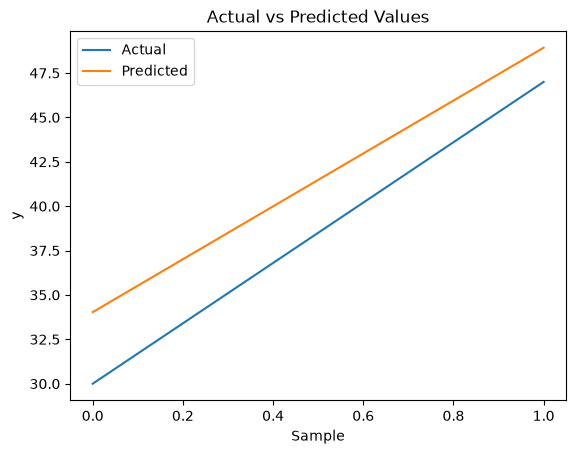

In [47]:
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Sample")
plt.ylabel("y")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()

### Data is very less thats why we got line like this but we have successfully trained a simple linear regression mdodel